In [1]:
import numpy as np

In [2]:
import pandas as pd

**Data Preprocesing**

In [39]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.py'
df = pd.read_csv('https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv')

df.columns = ['ID', 'Gender', 'Age', 'Income', 'Score']
print(df.head())

   ID  Gender  Age  Income  Score
0   1    Male   19      15     39
1   2    Male   21      15     81
2   3  Female   20      16      6
3   4  Female   23      16     77
4   5  Female   31      17     40


In [40]:
X = df[['Age', 'Income']].values
y = df['Score'].values

In [41]:
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = (y - y.mean()) / y.std()

In [42]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

**Vectorized Matrix Multiplication with NumPy**

In [43]:
weights = np.random.randn(2)
bias = 0
lr = 0.01

In [44]:
for epoch in range(1000):
    predictions = np.dot(X_train, weights) + bias
    error = predictions - y_train

    weights -= lr * (1/len(X_train)) * np.dot(X_train.T, error)
    bias -= lr * (1/len(X_train)) * np.sum(error)

print("Final Weights:", weights)

Final Weights: [-0.26464153  0.0223221 ]


**Testing & Result Visualization**

In [45]:
import matplotlib.pyplot as plt

In [46]:
y_pred = np.dot(X_test, weights) + bias

In [47]:
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

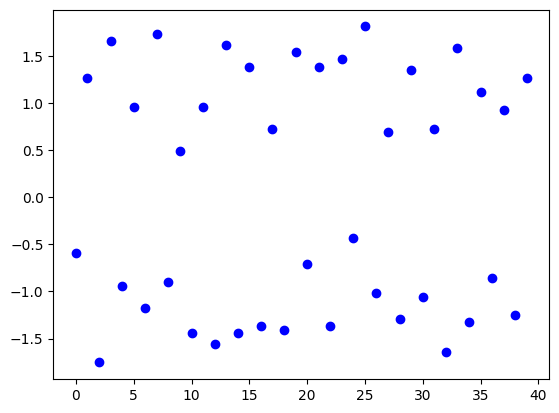

In [51]:
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')

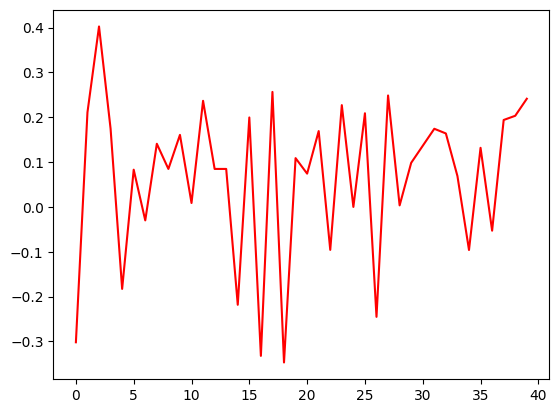

In [52]:
plt.plot(range(len(y_pred)), y_pred, color='red', label='Predicted')

Text(0.5, 1.0, 'Machine Performance: Actual vs Predicted')

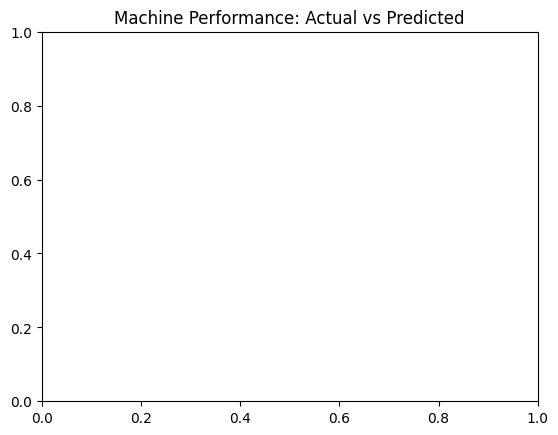

In [53]:
plt.title("Machine Performance: Actual vs Predicted")

/tmp/ipython-input-4061938096.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


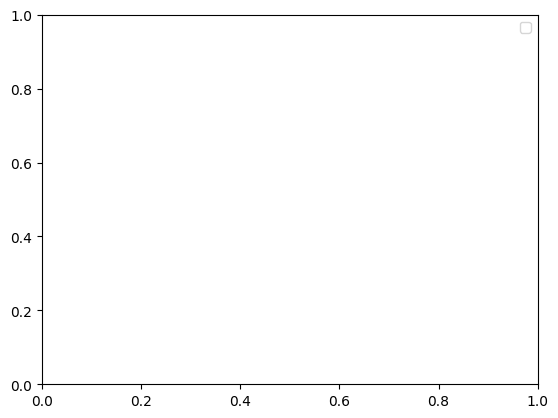

In [54]:
plt.legend()

In [55]:
plt.show()

In [56]:
mse = np.mean((y_test - y_pred)**2)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 1.3915
